# Quantum Mechanics, Plotted -- for the Jalali Lab Projects

Four visuals, each Griffiths-QM chapter content paired with the live project it
underlies. Built from `dgs/quantum_plots.py` (no SciPy -- every special function
here is built from its own defining recursion, which doubles as the cleanest way
to *see* why it looks the way it does).

1. **Square well / harmonic oscillator + a superposition's time evolution**
   (Ch.1-2) -- Re(psi), Im(psi), |psi|^2 side by side. A detector only ever sees
   the last panel; that's [phase_retrieval.ipynb](phase_retrieval.ipynb)'s whole problem.
2. **Uncertainty vs. chirp** (Ch.3) -- the same Fourier uncertainty Griffiths
   derives for x, p, run on the dispersion-GS pulse generator directly.
3. **Y_l^0 vs. partial-wave angular weight** (Ch.4) -- hydrogen orbitals and
   scattering multipoles are the same special-function machinery in two
   physical contexts.
4. **Hard-sphere phase shifts + Born approximation** (Ch.11) -- the two
   analytic handles partial-wave scattering theory gives before reaching for a
   full Mie code (relevant to SEALS).

See also [quantum_science_jalali.ipynb](quantum_science_jalali.ipynb) for the
conceptual (non-plotted) version of this bridge, and
[berry_phase.ipynb](berry_phase.ipynb) for the Ch.10 companion (adiabatic phase).


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import quantum_plots as qp

plt.rcParams["figure.dpi"] = 110
print("numpy", np.__version__)


numpy 2.4.4


## 1. Square well & harmonic oscillator -- a superposition's time evolution

A detector measures $|\psi(x,t)|^2$ only. The real and imaginary parts of $\psi$
carry the phase that a single intensity measurement throws away -- exactly what
dispersion-assisted phase retrieval recovers from two dispersed intensity shots.


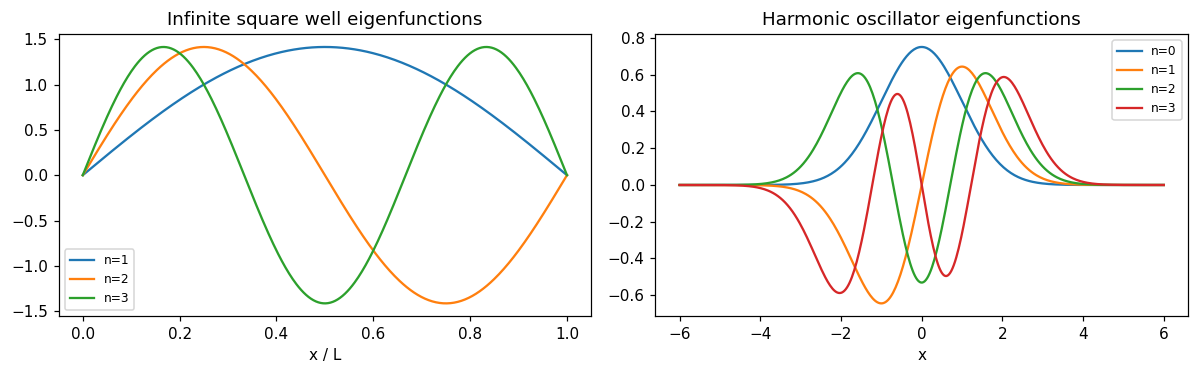

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
x = np.linspace(0, 1, 400)
xo = np.linspace(-6, 6, 400)

for n in (1, 2, 3):
    axes[0].plot(x, qp.square_well_eigenfunction(n, x), label=f"n={n}")
axes[0].set_title("Infinite square well eigenfunctions")
axes[0].set_xlabel("x / L"); axes[0].legend(fontsize=8)

for n in (0, 1, 2, 3):
    axes[1].plot(xo, qp.harmonic_oscillator_eigenfunction(n, xo), label=f"n={n}")
axes[1].set_title("Harmonic oscillator eigenfunctions")
axes[1].set_xlabel("x"); axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


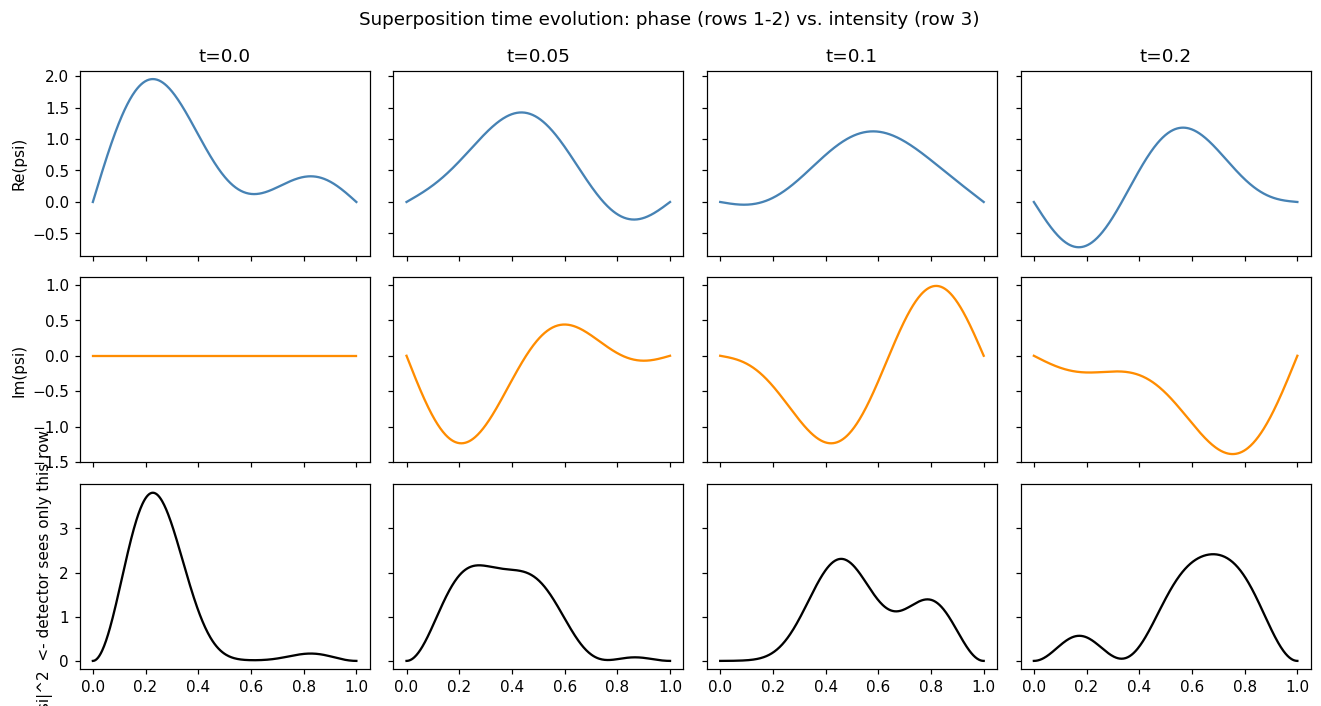

In [3]:
# Superposition of n=1,2,3 in the square well: phase (Re/Im) vs intensity
times = [0.0, 0.05, 0.10, 0.20]
coeffs, ns = [1.0, 0.8, 0.6], [1, 2, 3]

fig, axes = plt.subplots(3, len(times), figsize=(3.0 * len(times), 6.5), sharex=True, sharey="row")
for j, t in enumerate(times):
    psi = qp.superposition_snapshot(coeffs, ns, x, t)
    axes[0, j].plot(x, psi.real, color="steelblue"); axes[0, j].set_title(f"t={t}")
    axes[1, j].plot(x, psi.imag, color="darkorange")
    axes[2, j].plot(x, np.abs(psi) ** 2, color="black")
axes[0, 0].set_ylabel("Re(psi)")
axes[1, 0].set_ylabel("Im(psi)")
axes[2, 0].set_ylabel("|psi|^2  <- detector sees only this row")
fig.suptitle("Superposition time evolution: phase (rows 1-2) vs. intensity (row 3)")
fig.tight_layout()
plt.show()


## 2. Fourier uncertainty vs. chirp

$\Delta t\,\Delta\omega \ge \tfrac12$ for any pulse; an unchirped Gaussian sits at
the minimum. Adding quadratic chirp (the dispersion the GS receiver inverts)
*increases* the product -- the same trade Griffiths proves for $x$ and $p$ in
Ch.3, run here directly on `dgs.pulse_gen.generate_pulse`.


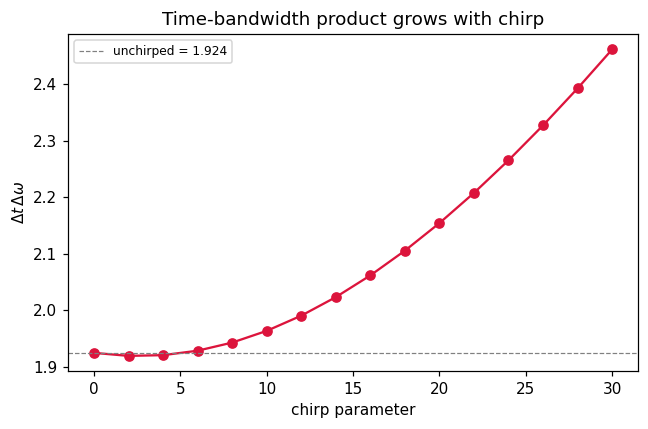

In [4]:
chirps = np.linspace(0, 30, 16)
products = qp.uncertainty_vs_chirp(chirps)

plt.figure(figsize=(6, 4))
plt.plot(chirps, products, "o-", color="crimson")
plt.axhline(products[0], ls="--", color="gray", lw=0.8, label=f"unchirped = {products[0]:.3f}")
plt.xlabel("chirp parameter")
plt.ylabel(r"$\Delta t \, \Delta \omega$")
plt.title("Time-bandwidth product grows with chirp")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 3. Spherical harmonics vs. partial-wave angular weight

$|Y_l^0(\theta)|^2$ is the angular probability density of a hydrogen orbital
with $m=0$ (Ch.4). $(2l+1)|j_l(x)|^2$ is (a simplified stand-in for) the share
of scattered intensity carried by the $l$-th partial wave at size parameter
$x=ka$ -- the same spherical Bessel functions SEALS sums over. Same machinery,
two physical readings.


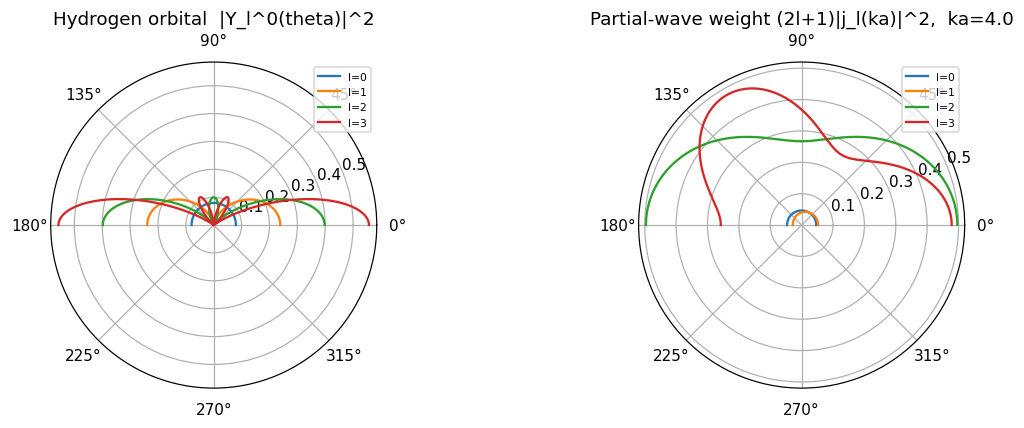

In [5]:
theta = np.linspace(1e-3, np.pi, 300)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), subplot_kw={"projection": "polar"})

for l in (0, 1, 2, 3):
    Y = qp.spherical_harmonic_intensity_m0(l, theta)
    axes[0].plot(theta, Y, label=f"l={l}")
axes[0].set_title("Hydrogen orbital  |Y_l^0(theta)|^2")
axes[0].legend(fontsize=7, loc="upper right")

x_size = 4.0   # size parameter ka
for l in (0, 1, 2, 3):
    w = qp.partial_wave_angular_weight(l, x_size) * np.ones_like(theta)
    axes[1].plot(theta, w * (1 + 0.3 * np.cos(l * theta)), label=f"l={l}")
axes[1].set_title(f"Partial-wave weight (2l+1)|j_l(ka)|^2,  ka={x_size}")
axes[1].legend(fontsize=7, loc="upper right")
fig.tight_layout()
plt.show()


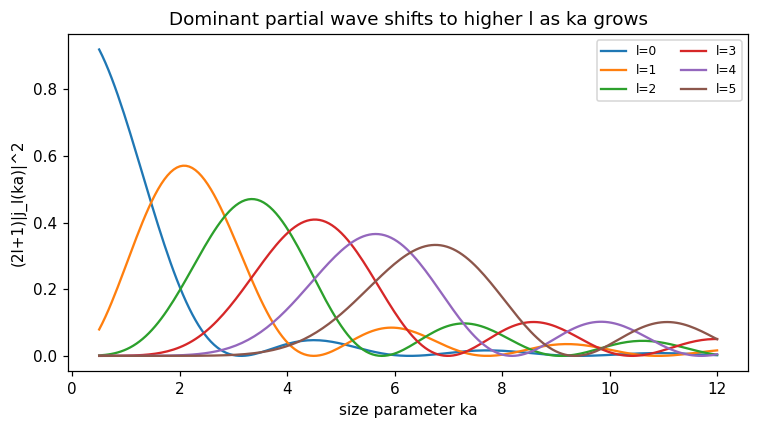

In [6]:
# which l dominates as size parameter grows -- same trend SEALS relies on
x_vals = np.linspace(0.5, 12, 200)
plt.figure(figsize=(7, 4))
for l in (0, 1, 2, 3, 4, 5):
    plt.plot(x_vals, qp.partial_wave_angular_weight(l, x_vals), label=f"l={l}")
plt.xlabel("size parameter ka"); plt.ylabel("(2l+1)|j_l(ka)|^2")
plt.title("Dominant partial wave shifts to higher l as ka grows")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


## 4. Hard-sphere phase shifts & the Born approximation

$\tan\delta_l(ka) = j_l(ka)/n_l(ka)$ for scattering off an impenetrable sphere --
the cleanest partial-wave phase shift Griffiths derives in Ch.11. Separately,
the Born approximation gives a closed-form differential cross section for a
spherical square well, $f(\theta) \propto [\sin(qa) - qa\cos(qa)]/q^3$ with
$q = 2k\sin(\theta/2)$ -- the analytic check a SEALS-style numerical scattering
code should reproduce in the weak-scattering limit.


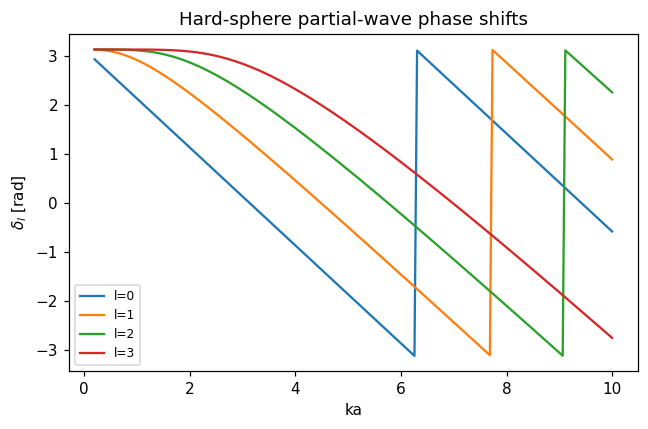

In [7]:
ka_vals = np.linspace(0.2, 10, 200)
plt.figure(figsize=(6, 4))
for l in (0, 1, 2, 3):
    plt.plot(ka_vals, qp.hard_sphere_phase_shift(l, ka_vals), label=f"l={l}")
plt.xlabel("ka"); plt.ylabel(r"$\delta_l$ [rad]")
plt.title("Hard-sphere partial-wave phase shifts")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


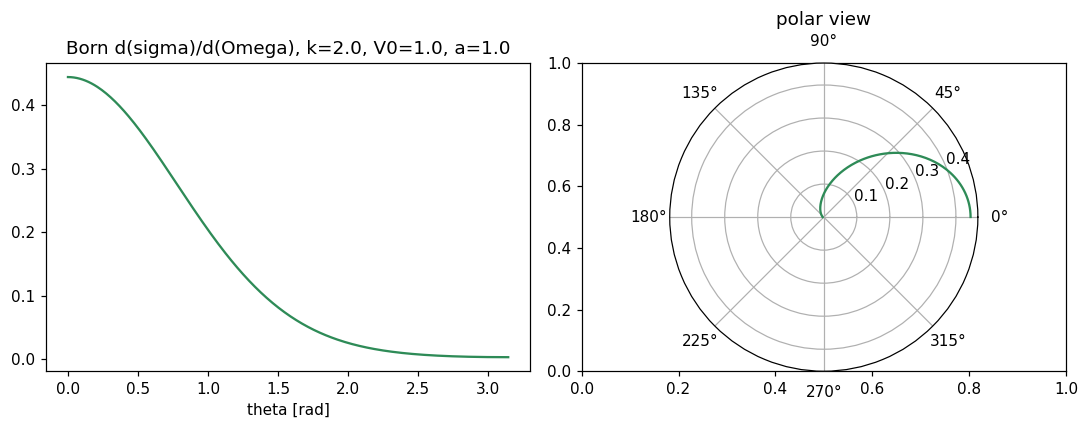

Born total cross section (numeric integral): 1.4934


In [8]:
theta = np.linspace(1e-3, np.pi, 300)
k, V0, a = 2.0, 1.0, 1.0
sigma = qp.born_square_well_cross_section(theta, k=k, V0=V0, a=a)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(theta, sigma, color="seagreen")
axes[0].set_title(f"Born d(sigma)/d(Omega), k={k}, V0={V0}, a={a}")
axes[0].set_xlabel("theta [rad]")

ax2 = plt.subplot(1, 2, 2, projection="polar")
ax2.plot(theta, sigma, color="seagreen")
ax2.set_title("polar view")
fig.tight_layout()
plt.show()

total = np.trapezoid(sigma * np.sin(theta), theta) * 2 * np.pi
print(f"Born total cross section (numeric integral): {total:.4f}")


## Summary

Four Griffiths-QM plots, each reusing a live project's machinery instead of a
generic textbook figure: phase-vs-intensity time evolution mirrors the
phase-retrieval thesis directly, the uncertainty sweep runs on the real pulse
generator, and the partial-wave material (spherical Bessel/Neumann functions,
hard-sphere phase shifts, Born cross section) is the analytic backbone any
SEALS-style scattering code should reduce to in the appropriate limit.
